In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import re
import collections
import torch.nn.functional as F

# Text dataset

In [2]:
!wget -O timemachine.txt http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt

--2026-03-22 11:05:38--  http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt
Resolving d2l-data.s3-accelerate.amazonaws.com (d2l-data.s3-accelerate.amazonaws.com)... 52.222.167.156
Connecting to d2l-data.s3-accelerate.amazonaws.com (d2l-data.s3-accelerate.amazonaws.com)|52.222.167.156|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 178979 (175K) [text/plain]
Saving to: ‘timemachine.txt’

timemachine.txt     100%[===================>] 174.78K   383KB/s    in 0.5s    

2026-03-22 11:05:38 (383 KB/s) - ‘timemachine.txt’ saved [178979/178979]



In [3]:
def read_data():
    with open("timemachine.txt", 'r') as f:
        return f.read()

data = read_data()
data[:40]

'The Time Machine, by H. G. Wells [1898]\n'

In [4]:
def process_text(text):
    return re.sub("[^A-Za-z]+", ' ', text).lower()

text = process_text(data)
text[:40]

'the time machine by h g wells i the time'

In [5]:
def tokenize(text): return list(text)
tokens = tokenize(text)
", ".join(tokens[:30])

't, h, e,  , t, i, m, e,  , m, a, c, h, i, n, e,  , b, y,  , h,  , g,  , w, e, l, l, s,  '

In [ ]:
class Vocab:
    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        self.idx_to_token = list(sorted(set(["<unk>"] + reserved_tokens + [t for t,f in self.token_freqs if f>min_freq])))
        self.token_to_idx = {t:i for i,t in enumerate(self.idx_to_token)}

    def __len__(self): return len(self.token_to_idx)

    @property
    def unk(self): return self.token_to_idx["<unk>"]

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.tokens_to_idx.get(tokens, self.unk)
        return [self.__getitem__(t) for t in tokens]
    
    def to_tokens(self, indices):
        if hasattr(indices, "__len__") and len(indices)>1:
            return [self.idx_to_token[int(i)] for i in indices]
        return self.idx_to_token[indices]

In [7]:
vocab = Vocab(tokens=tokens)
vocab[tokens[:10]]

[21, 9, 6, 0, 21, 10, 14, 6, 0, 14]

In [8]:
words = text.split()
vocab = Vocab(tokens=words)
vocab.token_freqs[:10]

[('the', 2261),
 ('i', 1267),
 ('and', 1245),
 ('of', 1155),
 ('a', 816),
 ('to', 695),
 ('was', 552),
 ('in', 541),
 ('that', 443),
 ('my', 440)]

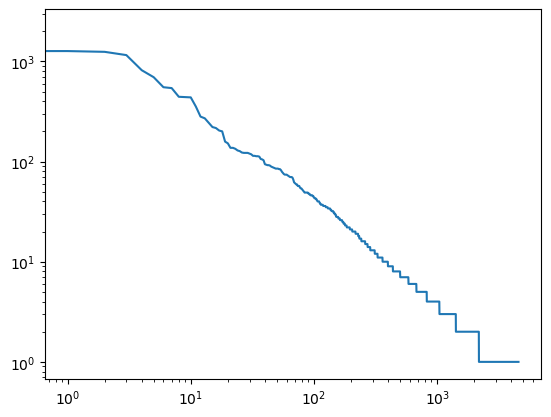

In [9]:
freqs = [f for _,f in vocab.token_freqs]
plt.loglog(freqs); plt.show()

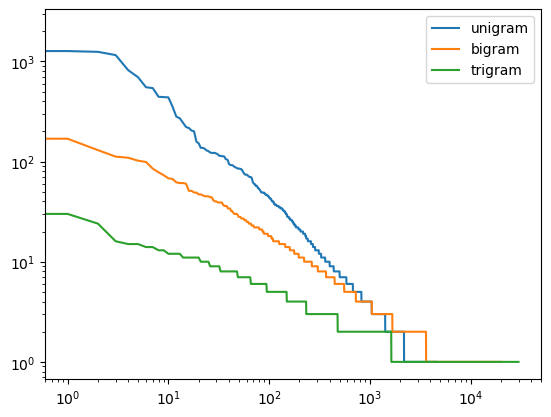

In [10]:
bigrams = ["--".join(p) for p in zip(words[:-1], words[1:])]
trigrams = ["--".join(t) for t in zip(words[:-2], words[1:-1], words[2:])]
bigram_vocab = Vocab(bigrams)
trigram_vocab = Vocab(trigrams)
plt.loglog([f for _,f in vocab.token_freqs], label="unigram")
plt.loglog([f for _,f in bigram_vocab.token_freqs], label="bigram")
plt.loglog([f for _,f in trigram_vocab.token_freqs], label="trigram")
plt.legend()
plt.show()

In [11]:
class TextData(torch.utils.data.Dataset):
    def __init__(self, text, num_steps):
        super(TextData, self).__init__()
        tokens = tokenize(text)
        self.vocab = Vocab(tokens=tokens)
        self.vocab_size = len(self.vocab)
        corpus = [self.vocab[token] for token in tokens]
        array = torch.tensor([corpus[i:i+num_steps+1] for i in range(len(corpus)-num_steps)])
        self.X = array[:,:-1]
        self.y = array[:,1:]

text_data = TextData(process_text(read_data()), 32)
# text_data.X.shape, text_data.y.shape
text_data.X, text_data.y

(tensor([[21,  9,  6,  ...,  0, 10,  0],
         [ 9,  6,  0,  ..., 10,  0, 21],
         [ 6,  0, 21,  ...,  0, 21,  9],
         ...,
         [20, 21, 10,  ...,  7,  0, 14],
         [21, 10, 13,  ...,  0, 14,  2],
         [10, 13, 13,  ..., 14,  2, 15]]),
 tensor([[ 9,  6,  0,  ..., 10,  0, 21],
         [ 6,  0, 21,  ...,  0, 21,  9],
         [ 0, 21, 10,  ..., 21,  9,  6],
         ...,
         [21, 10, 13,  ...,  0, 14,  2],
         [10, 13, 13,  ..., 14,  2, 15],
         [13, 13,  0,  ...,  2, 15,  0]]))

In [12]:
text_data.vocab.unk, text_data.vocab[' '], len(text_data.vocab)

(1, 0, 28)

In [13]:
num_train = 10000
num_val = 5000
train_indices = slice(0, num_train)
val_indices = slice(num_train, num_train+num_val)
def get_dataloader(text_data, indices, batch_size, shuffle):
    dataset = torch.utils.data.TensorDataset(text_data.X[indices], text_data.y[indices])
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return dataloader
train_dataloader = get_dataloader(text_data, train_indices, batch_size=1024, shuffle=True)
eval_dataloader = get_dataloader(text_data, val_indices, batch_size=1024, shuffle=False)

In [14]:
for x,y in train_dataloader:
    print("X:", x)
    print("y:", y)
    print("Shapes:", x.shape, y.shape)
    break

X: tensor([[20, 20,  0,  ..., 16, 13, 10],
        [ 6, 20, 17,  ..., 19,  2, 23],
        [16, 22,  0,  ...,  6, 14,  2],
        ...,
        [ 7, 21,  0,  ..., 24,  2, 19],
        [16, 15,  0,  ...,  5,  0,  9],
        [14,  6, 15,  ..., 22,  6,  0]])
y: tensor([[20,  0, 14,  ..., 13, 10, 20],
        [20, 17,  6,  ...,  2, 23, 10],
        [22,  0, 12,  ..., 14,  2, 21],
        ...,
        [21,  0, 24,  ...,  2, 19,  5],
        [15,  0, 10,  ...,  0,  9,  6],
        [ 6, 15, 20,  ...,  6,  0, 10]])
Shapes: torch.Size([1024, 32]) torch.Size([1024, 32])


# RNN

In [15]:
class RNNfromScratch(nn.Module): # RNN cell
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super(RNNfromScratch, self).__init__()
        self.num_hiddens = num_hiddens
        self.sigma = sigma
        self.W_xh = nn.Parameter(torch.randn((num_inputs, num_hiddens)) * sigma)
        self.W_hh = nn.Parameter(torch.randn(num_hiddens, num_hiddens) * sigma)
        self.b_h = nn.Parameter(torch.zeros(num_hiddens))
    
    def forward(self, inputs, state=None):
        # inputs shape is: (num_steps, batch_size, num_inputs)
        if state is None:
            # inputs.size(1) is batch_size
            state = torch.zeros((inputs.size(1), self.num_hiddens), device=inputs.device)
        else: state, = state
        outputs = []
        for x in inputs: # shape of inputs: (num_steps, batch_size, num_inputs)
            # for each step
            # print(f"sequence {len(outputs)} shape:", x.shape)
            state = torch.tanh(torch.matmul(x, self.W_xh) + torch.matmul(state, self.W_hh) + self.b_h)
            outputs.append(state)
        return outputs, state

In [16]:
batch_size = 8
num_inputs = 16 # feature dim
num_hiddens = 32
num_steps = 32

rnn = RNNfromScratch(num_inputs=num_inputs, num_hiddens=num_hiddens)
X = torch.ones((num_steps, batch_size, num_inputs))
outputs, state = rnn(X)
len(outputs) ,state.shape

(32, torch.Size([8, 32]))

In [17]:
class RNNLMfromScratch(nn.Module):
    def __init__(self, rnn, vocab_size):
        super(RNNLMfromScratch, self).__init__()
        self.W_hq = nn.Parameter(torch.randn(rnn.num_hiddens, vocab_size) * rnn.sigma)
        self.b_q = nn.Parameter(torch.zeros(vocab_size))
        self.vocab_size = vocab_size
        self.rnn = rnn
    
    def one_hot(self, x):
        # x shape: (batch_size, num_steps)
        # output shape: (num_steps, batch_size, vocab_size)
        return F.one_hot(x.T, self.vocab_size).type(torch.float32)

    def forward(self, x, state=None):
        embeddings = self.one_hot(x)
        # print(embeddings.shape)
        rnn_outputs, state = self.rnn(embeddings, state)
        outputs = [torch.matmul(H, self.W_hq) + self.b_q for H in rnn_outputs]
        # for o in outputs: print(o.shape); break
        return torch.stack(outputs, dim=1), state

In [18]:
x = torch.ones((batch_size, num_steps), dtype=torch.int64)
print(x.shape, F.one_hot(x, num_inputs).shape)
model = RNNLMfromScratch(rnn, num_inputs)
out, state = model(x)
print(out.shape)

torch.Size([8, 32]) torch.Size([8, 32, 16])
torch.Size([8, 32, 16])


In [19]:
def grad_clip(clip_val, model):
    params = [p for p in model.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
    if norm > clip_val:
        for p in params:
            p.grad[:] *= clip_val / norm

In [20]:
def train_rnn(model, max_epochs, clip_val, lr, train_dataloader, eval_dataloader, report_every):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    metrics = {"train_loss": [], "train_ppl": [], "eval_loss": [], "eval_ppl": []}
    criterion = nn.CrossEntropyLoss()

    model = model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr)

    for epoch in range(max_epochs):
        model.train()
        num_instances = 0
        epoch_loss = 0.
        epoch_ppl = 0.
        for step, batch in enumerate(train_dataloader):
            optimizer.zero_grad()
            batch = [a.to(device) for a in batch]
            bs = batch[-1].size(0)
            logits, _ = model(*batch[:-1])
            logits = logits.reshape(-1, logits.shape[-1])
            loss = criterion(logits, batch[-1].reshape(-1))
            loss.backward()
            grad_clip(clip_val, model)
            optimizer.step()
            epoch_loss += loss.item() * bs
            epoch_ppl += torch.exp(loss).item() * bs
            num_instances += bs

        epoch_loss /= num_instances
        epoch_ppl /= num_instances
        metrics["train_loss"].append(epoch_loss)
        metrics["train_ppl"].append(epoch_ppl)
        if epoch % report_every==0:
            print(f"[{epoch}/{max_epochs}] train_loss: {epoch_loss:.5f}, train_ppl: {epoch_ppl:.5f}")

        model.eval()
        num_instances = 0
        epoch_loss = 0.
        epoch_ppl = 0.
        for step, batch in enumerate(eval_dataloader):
            batch = [a.to(device) for a in batch]
            bs = batch[-1].size(0)
            with torch.no_grad():
                logits, _ = model(*batch[:-1])
                logits = logits.reshape(-1, logits.shape[-1])
                loss = criterion(logits, batch[-1].reshape(-1))
                epoch_loss += loss.item() * bs
                epoch_ppl += torch.exp(loss).item() * bs
            num_instances += bs

        epoch_loss /= num_instances
        epoch_ppl /= num_instances
        metrics["eval_loss"].append(epoch_loss)
        metrics["eval_ppl"].append(epoch_ppl)
        if epoch % report_every==0:
            print(f"[{epoch}/{max_epochs}] eval_loss: {epoch_loss:.5f}, eval_ppl: {epoch_ppl:.5f}")
            
    return metrics
    

In [21]:
len(text_data.vocab)

28

In [22]:
vocab_size = text_data.vocab_size
rnn = RNNfromScratch(num_inputs=vocab_size, num_hiddens=32)
model = RNNLMfromScratch(rnn=rnn, vocab_size=vocab_size)
metrics = train_rnn(model, max_epochs=100, clip_val=1, lr=1, train_dataloader=train_dataloader, eval_dataloader=eval_dataloader, report_every=10)


[0/100] train_loss: 3.18572, train_ppl: 24.27074
[0/100] eval_loss: 3.04120, eval_ppl: 20.93193
[10/100] train_loss: 2.66031, train_ppl: 14.30406
[10/100] eval_loss: 2.57784, eval_ppl: 13.17469
[20/100] train_loss: 2.34490, train_ppl: 10.43274
[20/100] eval_loss: 2.30584, eval_ppl: 10.04055
[30/100] train_loss: 2.23229, train_ppl: 9.32172
[30/100] eval_loss: 2.23321, eval_ppl: 9.33798
[40/100] train_loss: 2.15068, train_ppl: 8.59110
[40/100] eval_loss: 2.21405, eval_ppl: 9.16361
[50/100] train_loss: 2.07318, train_ppl: 7.95101
[50/100] eval_loss: 2.13475, eval_ppl: 8.46412
[60/100] train_loss: 2.01109, train_ppl: 7.47210
[60/100] eval_loss: 2.10755, eval_ppl: 8.24300
[70/100] train_loss: 1.94014, train_ppl: 6.96001
[70/100] eval_loss: 2.04345, eval_ppl: 7.73356
[80/100] train_loss: 1.89691, train_ppl: 6.66546
[80/100] eval_loss: 2.01729, eval_ppl: 7.53438
[90/100] train_loss: 1.85997, train_ppl: 6.42411
[90/100] eval_loss: 1.99482, eval_ppl: 7.37111


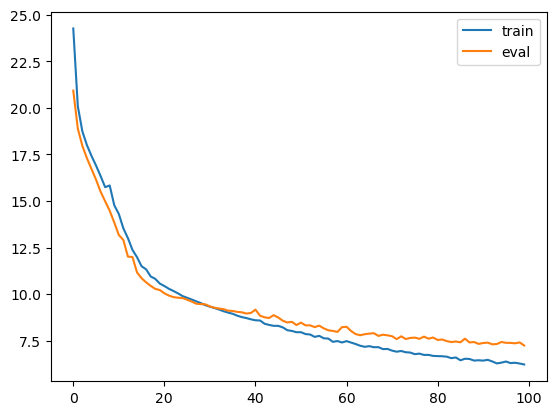

In [23]:
plt.plot(metrics["train_ppl"], label="train")
plt.plot(metrics["eval_ppl"], label="eval")
plt.legend(); plt.show()

In [24]:
def predict_last(prefix, num_preds, model, vocab, device):
    state, outputs = None, [vocab[prefix[0]]]
    model.eval()
    with torch.no_grad():
        for i in range(len(prefix)+num_preds-1):
            if i<len(prefix)-1:
                outputs.append(vocab[prefix[i+1]])
            else:
                x = torch.tensor([[outputs[-1]]], device=device)
                logits, state = model(x, state)
                pred_idx = logits.argmax(dim=2).reshape(1)
                outputs.append(int(pred_idx))
        return "".join(vocab.idx_to_token[i] for i in outputs)

def predict(prefix, num_preds, model, vocab, device):
    state, outputs = None, [vocab[prefix[0]]]
    model.eval()
    with torch.no_grad():
        for i in range(len(prefix)+num_preds-1):
            # x = torch.tensor([[outputs[-1]]], device=device)
            if i<len(prefix)-1:
                outputs.append(vocab[prefix[i+1]])
            else:
                x = torch.tensor([outputs], device=device)
                logits, state = model(x, state)
                pred_idx = logits.argmax(dim=2).reshape(-1)
                outputs.append(int(pred_idx[-1]))
        return "".join(vocab.idx_to_token[i] for i in outputs)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [25]:
predict_last("it has", 20, model, text_data.vocab, device)

'it has and the the the the'

In [26]:
predict("it has", 20, model, text_data.vocab, device)

'it has in the the the the '

In [27]:
class RNN(nn.Module):
    def __init__(self, num_inputs, num_hiddens):
        super(RNN, self).__init__()
        self.rnn = nn.RNN(input_size=num_inputs, hidden_size=num_hiddens)
        self.num_hiddens = num_hiddens

    def forward(self, x, hidden=None):
        return self.rnn(x, hidden)
    


In [28]:
bs = 4
seq_len = 32
num_inputs = 100
x = torch.ones((bs,seq_len,num_inputs))
rnn = RNN(num_inputs, 32)
out, hidden = rnn(x)
out.shape, hidden.shape

(torch.Size([4, 32, 32]), torch.Size([1, 32, 32]))

In [29]:
class RNNLM(nn.Module):
    def __init__(self, rnn, vocab_size):
        super(RNNLM, self).__init__()
        self.linear = nn.Linear(in_features=rnn.num_hiddens, out_features=vocab_size)
        self.rnn = rnn
        self.vocab_size = vocab_size
    
    def one_hot(self, x):
        # x shape: (batch_size, num_steps)
        return F.one_hot(x.T, self.vocab_size).type(torch.float32)

    def forward(self, x, hidden=None):
        embeddings = self.one_hot(x)
        rnn_out, state = self.rnn(embeddings, hidden)
        return self.linear(rnn_out).swapaxes(0,1), state

In [30]:
rnn = RNN(405, 32)
rnn_lm = RNNLM(rnn, 405)
x = torch.ones((bs,seq_len)).type(torch.int64)
rnn_lm(x, None)[0].shape

torch.Size([4, 32, 405])

In [31]:
vocab_size = text_data.vocab_size
rnn = RNN(num_inputs=vocab_size, num_hiddens=32)
model = RNNLM(rnn=rnn, vocab_size=vocab_size)
metrics = train_rnn(model, max_epochs=100, clip_val=1, lr=1, train_dataloader=train_dataloader, eval_dataloader=eval_dataloader, report_every=10)


[0/100] train_loss: 2.99315, train_ppl: 20.19341
[0/100] eval_loss: 2.84147, eval_ppl: 17.14810
[10/100] train_loss: 2.36675, train_ppl: 10.66353
[10/100] eval_loss: 2.32592, eval_ppl: 10.24047
[20/100] train_loss: 2.17752, train_ppl: 8.82479
[20/100] eval_loss: 2.20469, eval_ppl: 9.07663
[30/100] train_loss: 2.07399, train_ppl: 7.95678
[30/100] eval_loss: 2.13200, eval_ppl: 8.44245
[40/100] train_loss: 2.00580, train_ppl: 7.43293
[40/100] eval_loss: 2.08804, eval_ppl: 8.08261
[50/100] train_loss: 1.94609, train_ppl: 7.00151
[50/100] eval_loss: 2.07726, eval_ppl: 7.99604
[60/100] train_loss: 1.88829, train_ppl: 6.60875
[60/100] eval_loss: 2.03631, eval_ppl: 7.67744
[70/100] train_loss: 1.85433, train_ppl: 6.38765
[70/100] eval_loss: 2.03995, eval_ppl: 7.70989
[80/100] train_loss: 1.84127, train_ppl: 6.30632
[80/100] eval_loss: 2.02440, eval_ppl: 7.58904
[90/100] train_loss: 1.82311, train_ppl: 6.19169
[90/100] eval_loss: 2.00571, eval_ppl: 7.45775


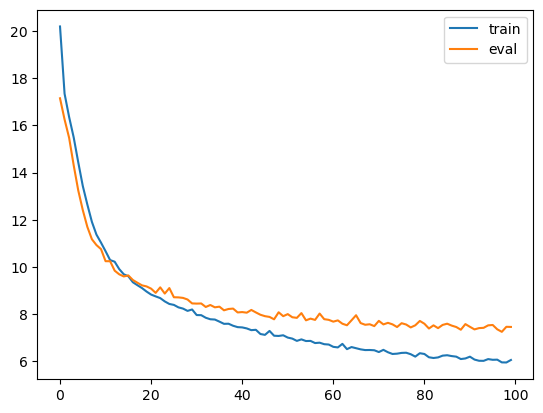

In [32]:
plt.plot(metrics["train_ppl"], label="train")
plt.plot(metrics["eval_ppl"], label="eval")
plt.legend(); plt.show()

In [33]:
predict_last("it has", 20, model, text_data.vocab, device)

'it has of the padeed and a'

In [34]:
predict("it has", 20, model, text_data.vocab, device)

'it has in the padeed and a'